In [1]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

In [2]:
import matplotlib.pyplot as plt

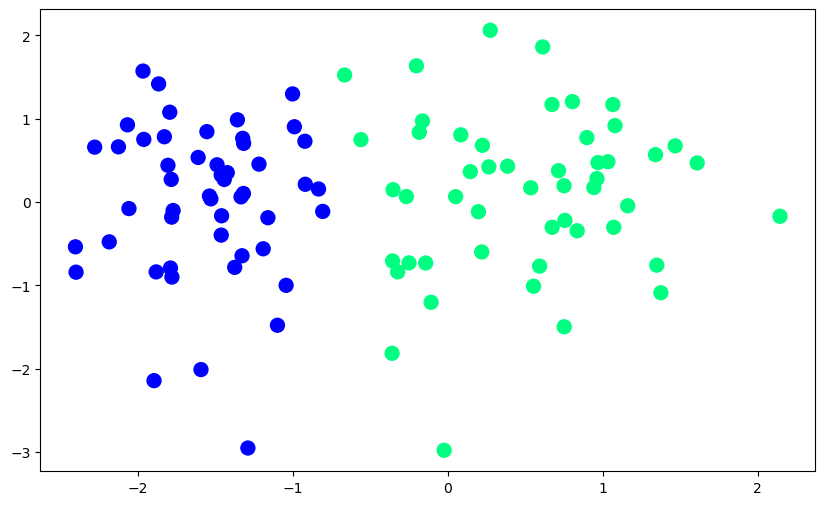

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [18]:
def perceptron(X,y):
    X=np.insert(X,0,1,axis=1)#har row ke aage 1 insert kar diya
    weights=np.ones(X.shape[1])#ek weight vector banaya jisme jitne features hai utne weights 1 se initialize kiye
    lr=0.1
    for i in range(1000):
        j=np.random.randint(0,100)#randomly ek row select kiya
        y_hat=step(np.dot(X[j],weights))#wo fandom point aur weight ka dot product nikal ke step function me dala agr ye value greater than 0 hoga to 1 return karega otherwise 0
        weights=weights+lr*(y[j]-y_hat)*X[j]#weight update kiya,nya wala weight = purana weight + learning rate * (actual value - predicted value) * input features
    return weights[0],weights[1:]#return kiya bias aur weights


In [19]:
def step(x):
    return 1 if x>0 else 0

In [20]:
intercept_,coef_=perceptron(X,y)

In [21]:
print("intercept:",intercept_)
print("coef:",coef_)

intercept: 0.9
coef: [1.3305365  0.13275836]


In [22]:
m=-coef_[0]/coef_[1]
b=-intercept_/coef_[1]#slope aur intercept nikal liya

In [23]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

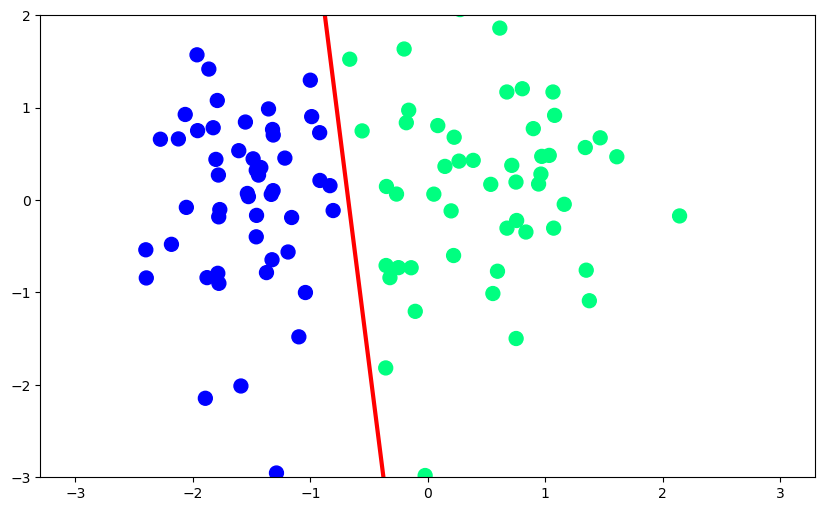

In [24]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [25]:
from sklearn.linear_model import LogisticRegression
lor=LogisticRegression()
lor.fit(X,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
m=-(lor.coef_[0][0]/lor.coef_[0][1])
b=-lor.intercept_/lor.coef_[0][1]

In [27]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

(-3.0, 2.0)

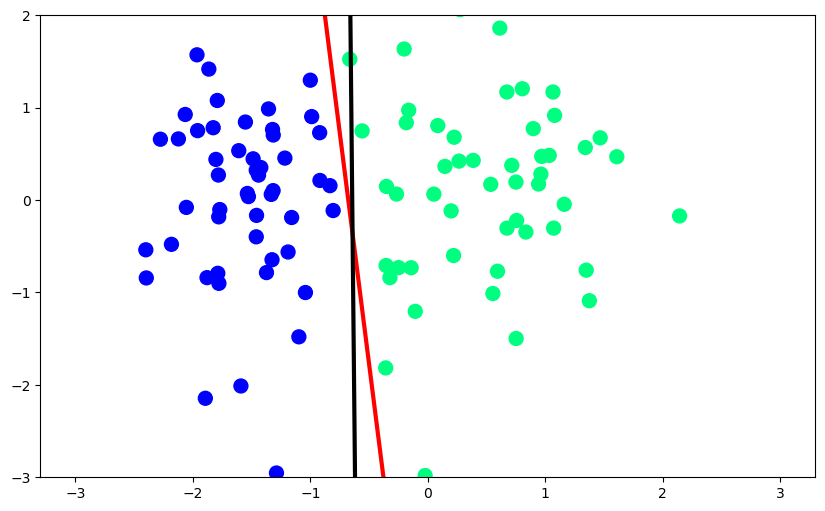

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)#sikit learn thoda advance hai isliye iska decision boundary thoda alag hoga, perceptron ka decision boundary linear hai aur logistic regression ka bhi linear hai lekin dono ke coefficients alag hai isliye dono ke decision boundary alag hai